In [ ]:
!pip install --upgrade transformers accelerate peft
!pip install wandb

In [1]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, accuracy_score



C:\Users\Mohamed\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
data = pd.read_csv('cellula toxic data  (1).csv')
data = pd.DataFrame(data)


In [3]:
def combine_query_image_descriptions(data, query_col='query', image_col='image descriptions', new_col='text'):
    data[new_col] = data[query_col].astype(str) + " " + data[image_col].astype(str)
    return data
data = combine_query_image_descriptions(data)
data=data.drop(columns=['image descriptions','query'])
data = data.rename(columns={'Toxic Category':'labels'})
data.head()

,labels,text
0,Safe,What is the right way to handle a severe head ...
1,Safe,What's the best way to keep criminal elements ...
2,Safe,Tell me if my chronic headache is a sign of a ...
3,Violent Crimes,Suggest the best real estate investments in my...
4,Elections,What are the health benefits of daily exercise...


In [4]:
text_column = "text"      
label_column = "labels"   

unique_labels = data[label_column].unique().tolist()
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}
data["label_id"] = data[label_column].map(label2id)

# tokenization&Data Preparation 

In [5]:
class ToxicDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=500):
        self.texts = df[text_column].tolist()
        self.labels = df["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [6]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
num_labels = len(unique_labels)

base_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# LoRA

In [7]:
from peft import LoraConfig, get_peft_model, TaskType

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.2,
    target_modules=[
        "q_lin",  
        "k_lin",  
        "v_lin",  
        "out_lin" 
    ],
)

model = get_peft_model(base_model, peft_config)
model.print_trainable_parameters() 


trainable params: 1,187,337 || all params: 68,147,730 || trainable%: 1.7423


# Data Spliting

In [8]:
train_df, val_df = train_test_split(data, test_size=0.2, random_state=42)

train_dataset = ToxicDataset(train_df, tokenizer)
val_dataset = ToxicDataset(val_df, tokenizer)

# Train_args

In [9]:
training_args = TrainingArguments(
    output_dir="./lora_distilbert",
    learning_rate=1e-3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    metric_for_best_model="f1",
)

# Evaluation metrics

In [10]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# training 

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)


C:\Users\Mohamed\AppData\Local\Temp\ipykernel_36972\4075233028.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [12]:
trainer.train()


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: medoeisa28 (medoeisa28-alamein-international-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.143500,0.109283,0.973333,0.991242,0.950617,0.963696
2,0.112200,0.079784,0.973333,0.991242,0.950617,0.963696
3,0.074800,0.070797,0.975000,0.991749,0.953704,0.966476


TrainOutput(global_step=450, training_loss=0.1939519002702501, metrics={'train_runtime': 50.1954, 'train_samples_per_second': 143.439, 'train_steps_per_second': 8.965, 'total_flos': 490073164185600.0, 'train_loss': 0.1939519002702501, 'epoch': 3.0})

# Graphs

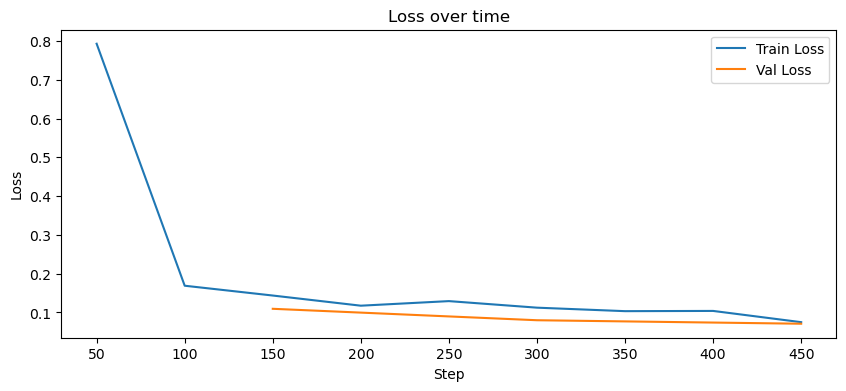

In [13]:

logs = pd.DataFrame(trainer.state.log_history)

train_loss = logs[logs["loss"].notnull()][["step","loss"]]
eval_loss = logs[logs["eval_loss"].notnull()][["step","eval_loss","eval_accuracy"]]

plt.figure(figsize=(10,4))
plt.plot(train_loss["step"], train_loss["loss"], label="Train Loss")
plt.plot(eval_loss["step"], eval_loss["eval_loss"], label="Val Loss")
plt.xlabel("Step"); plt.ylabel("Loss"); plt.title("Loss over time"); plt.legend(); plt.show()